In [33]:
import os
import copy
import cantera as ct
import numpy as np
import pandas as pd
import concurrent.futures
import subprocess

import matplotlib.pyplot as plt
%matplotlib inline


In [3]:
fuel_yaml = '/home/moon/autoscience/dib/DIB_MAX_1/DIB_MAX2.yaml'
gas = ct.Solution(fuel_yaml)

/home/moon/anaconda3/envs/rmg_env/lib/python3.7/site-packages/ipykernel_launcher.py:2: DeprecationWarning: Chebyshev reaction equation: Specifying '(+M)' in the reaction equation for Chebyshev reactions is deprecated.
On line 2487 of /home/moon/autoscience/dib/DIB_MAX_1/DIB_MAX2.yaml:
|  Line |
|  2482 |   rate-constant: {A: 1.41e+05, b: 1.836, Ea: 19.82}
|  2483 |   note: |-
|  2484 |     Reaction index: Chemkin #83; RMG #83
|  2485 |     Library reaction: CurranPentane
|  2486 |     Flux pairs: IC4H7O2(386), IC4H6OOH-I(387);
>  2487 > - equation: C[C]1CC1(721) (+M) <=> IC4H7(282) (+M)  # Reaction 84
            ^
|  2488 |   type: Chebyshev
|  2489 |   temperature-range: [300.0, 2000.0]
|  2490 |   pressure-range: [0.01 atm, 98.692 atm]

  


In [4]:
gas.n_reactions

649

In [6]:
# Load the experimental conditions
ignition_delay_data = '/work/westgroup/harris.se/autoscience/reaction_calculator/experiment/dib_ignition_delay.csv'
ignition_delay_data = '/home/moon/autoscience/autoscience_workflow/experiment/dib_ignition_delay.csv'

df_exp = pd.read_csv(ignition_delay_data)

# grab just the Metcalfe 2007 phi=1.0 data P=1.0 atm (table 16)
# ref_table = df_exp[df_exp['Table'] == 16]

# # grab just the Wu 2020 phi=1.0 data P=20.0 atm (table 5)
# ref_table = df_exp[df_exp['Table'] == 5]

# grab just the Metcalfe 2007 DIB phi=0.5 data P=4 atm (table 24)
ref_table = df_exp[df_exp['Table'] == 24]

# Define Initial conditions using experimental data
taus = ref_table['Time (ms)'].values.astype(float)  # ignition delay
Ts = ref_table['T (K)'].values  # Temperatures
Ps = ref_table['Pressure (bar)'].values * 1e5 / ct.one_atm  # pressures in atm
phi = ref_table['Phi'].values[0]
author = ref_table['Author'].values[0]

# list of starting conditions
concentrations = []
conc_dict = {
    'DIB1(1)': ref_table['DIB1'].values[0],
    'DIB2(2)': ref_table['DIB2'].values[0],
    'O2(3)': ref_table['O2'].values[0],
    'Ar': ref_table['Ar'].values[0]
}
concentrations = [conc_dict for i in range(len(ref_table))]

In [8]:
T_start = 1000
P_start = 101325
X_start = conc_dict

# function to run a RCM simulation

t_end = 1.0  # time in seconds
gas.TPX = T_start, P_start, X_start

env = ct.Reservoir(ct.Solution('air.yaml'))
reactor = ct.IdealGasReactor(gas)
wall = ct.Wall(reactor, env, A=1.0, velocity=0)
reactor_net = ct.ReactorNet([reactor])

times = [0]
T = [reactor.T]
P = [reactor.thermo.P]
X = [reactor.thermo.X]  # mol fractions
while reactor_net.time < t_end:
    reactor_net.step()

    times.append(reactor_net.time)
    T.append(reactor.T)
    P.append(reactor.thermo.P)
    X.append(reactor.thermo.X)

slopes = np.gradient(P, times)
i = np.argmax(slopes)


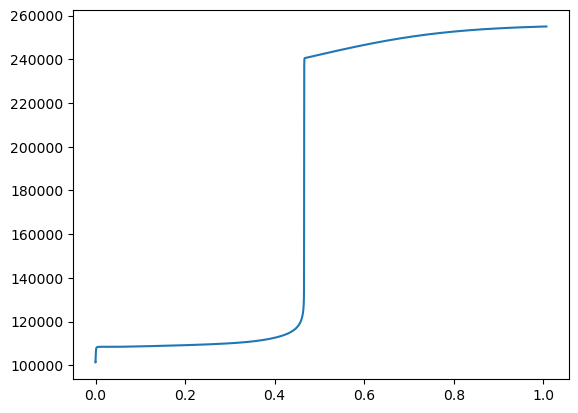

In [10]:
plt.plot(times, P)

In [57]:
slopes = np.gradient(P, times)
votes = [0]  # 0 gets to vote for itself
for i in range(1, len(times)):
    
    votes.append(np.argmax(slopes[0:i]))

In [70]:
# count up the votes
totals = np.zeros(len(times))
for i in range(len(times)):
    totals[i] = np.sum(np.array(votes) == i)

totals_copy = copy.deepcopy(totals)


In [86]:
# get top 3
n = 3
top_n_indices = []
sorted(totals)
for i in range(0, n):
    vote_count = sorted(totals)[-1 - i]
    time_index = list(totals_copy).index(vote_count)
    top_n_indices.append(time_index)


[662, 3556, 161]

In [133]:
def get_index_of_closest_time(t_ref):
    t_diff = np.abs(np.array(times) - t_ref)
    min_diff = min(t_diff)
    return list(t_diff).index(min_diff)

In [134]:
def check_valid_ignition(time_index):
    pressures = P[: time_index + 1]
    return np.max(pressures) / P[0] > 1.5

main_ignition_index = max(top_n_indices)
assert check_valid_ignition(main_ignition_index)

In [152]:
# get 2nd largest
first_ignition_index = sorted(top_n_indices)[-2]

# zoom in on it
flat_level = np.median(P[:main_ignition_index])

first_entrance = -1
first_exit = -1
ratio = 1.1
for i in range(len(times)):
    if P[i] > flat_level / ratio:
        first_entrance = i
        break
assert first_entrance != -1

for i in range(first_entrance, len(times)):
    if P[i] > flat_level * ratio:
        first_exit = i
        break
assert first_exit != -1

t_entrance = times[first_entrance]
t_exit = times[first_exit]
t_halfway = (t_exit - t_entrance) / 2.0
t_tenthway = (t_exit - t_entrance) / 10

# look at the halfway point and see what it voted for
halfway_index = get_index_of_closest_time(t_halfway)
halfway_vote = np.argmax(slopes[0:halfway_index])
assert halfway_vote == first_ignition_index


tenthway_index = get_index_of_closest_time(t_tenthway)
tenthway_vote = np.argmax(slopes[0:tenthway_index])
assert tenthway_vote == first_ignition_index

In [155]:
switch_index = -1
ignitions = [check_valid_ignition(t) for t in range(len(times))]
for i in range(1, len(ignitions)):
    if ignitions[i] and not ignitions[i - 1]:
        switch_index = i
        break

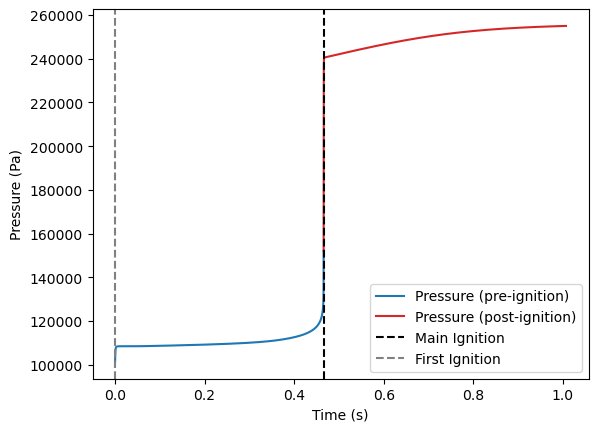

In [159]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.plot(times[:switch_index], P[:switch_index], color=colors[0], label='Pressure (pre-ignition)')
plt.plot(times[switch_index:], P[switch_index:], color=colors[3], label='Pressure (post-ignition)')


plt.ylabel('Pressure (Pa)')
plt.xlabel('Time (s)')

plt.axvline(x=times[main_ignition_index], color='black', linestyle='--', label='Main Ignition')

plt.axvline(x=times[halfway_vote], color='grey', linestyle='--', label='First Ignition')

plt.legend()

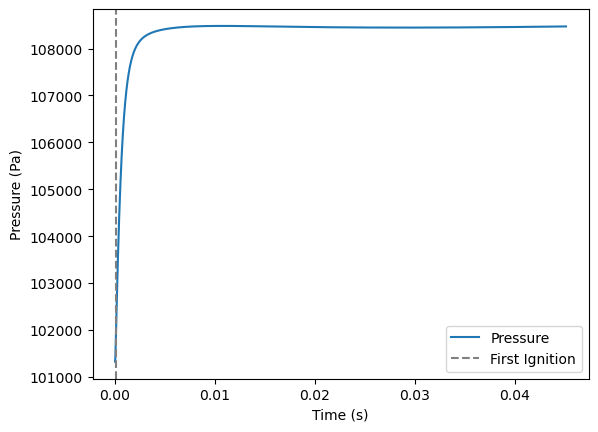

In [154]:
plt.plot(times[:tenthway_index], P[:tenthway_index], label='Pressure')
plt.ylabel('Pressure (Pa)')
plt.xlabel('Time (s)')

plt.axvline(x=times[halfway_vote], color='grey', linestyle='--', label='First Ignition')

plt.legend()

In [112]:
ignitions = [check_valid_ignition(t) for t in range(len(times))]

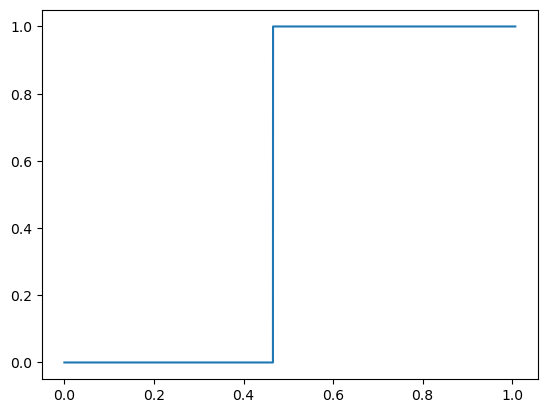

In [114]:
plt.plot(times, ignitions)

In [105]:
check_valid_ignition(662)

False

In [111]:
check_valid_ignition(1663)

False

In [106]:
times[662]

9.289289726604143e-05

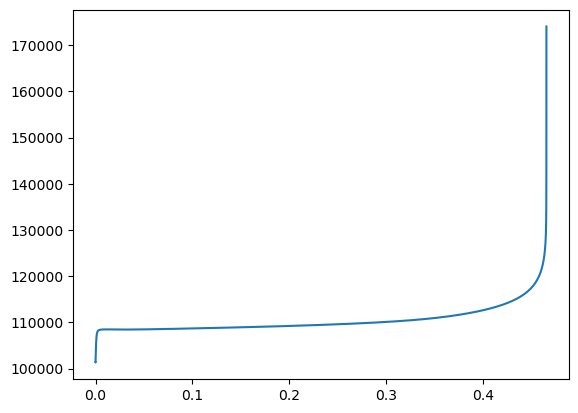

In [124]:
plt.plot(times[:3550], P[:3550])

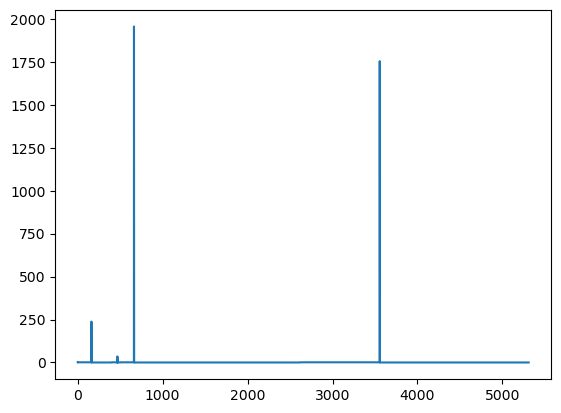

In [72]:
plt.plot(totals_copy)

In [41]:
# Rank indices by # votes

# get top 5 values

# totals


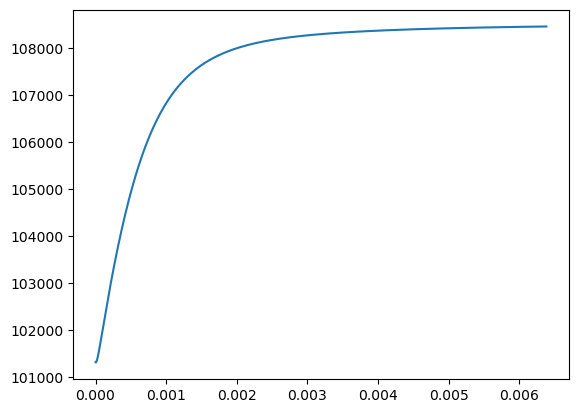

In [46]:
plt.plot(times[:i1*2], P[:i1*2])

In [52]:
times[1600]

0.07782354156919664

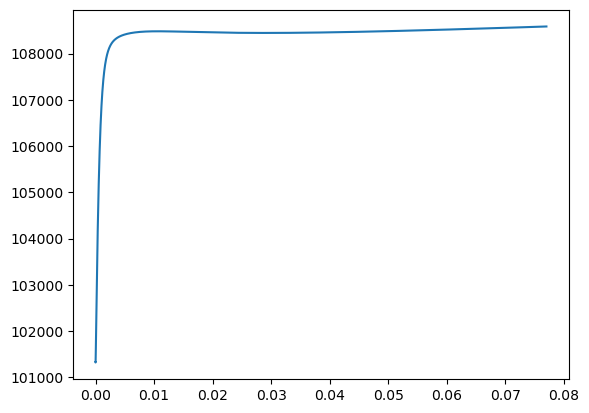

In [53]:
plt.plot(times[:1600], P[:1600])

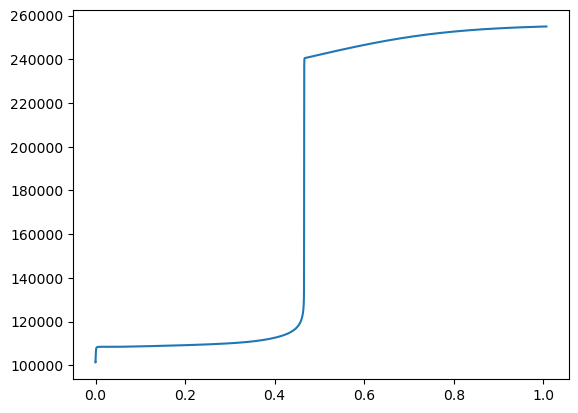

In [47]:
plt.plot(times[:i2*2], P[:i2*2])

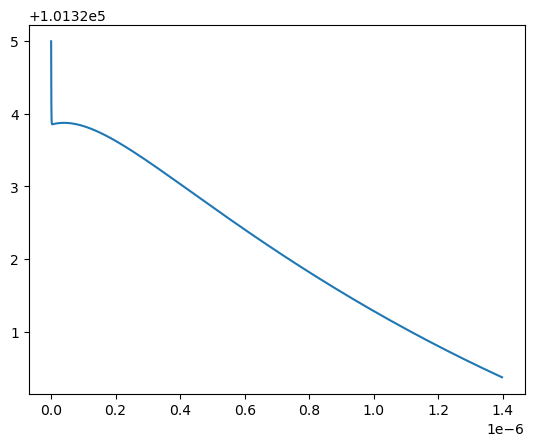

In [48]:
plt.plot(times[:i3*2], P[:i3*2])

In [42]:
times[i1]

9.289289726604143e-05

In [43]:
times[i2]

0.46570226556735955

In [44]:
times[i3]

5.801380953208379e-09

In [27]:
np.sum(totals)

5310.0

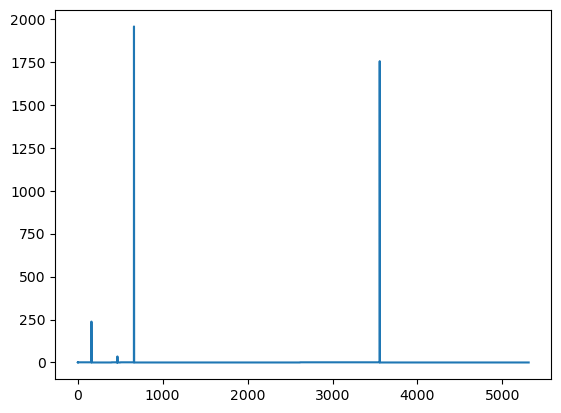

In [28]:
plt.plot(totals)

In [29]:
times[1000]

0.001004673400072191

In [31]:
times[100]

1.613587611001334e-09

In [ ]:
plt.plot

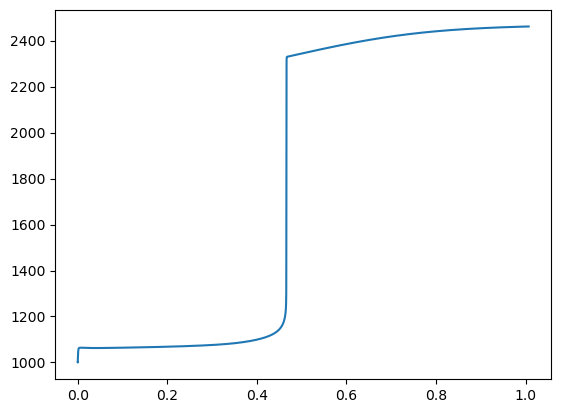

In [9]:
plt.plot(times, T)